## Importing Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

## Load Data

### 1. Weather Data

**Column Details**

- `Month` : Month of data record
- `District` : Name of the district
- `RainFall` : Average Cumulative Rainfall in mm
- `Min_Temp` : Average Minimum Temperature in celcius
- `Max_Temp` : Average Maximum Temperature in celcius
- `Min_Humidity` : AverageMinimum Humidity %
- `Max_Humidity` : Average Maximum Humidity %
- `Std_Rainfall` : Standard deviation of daily rainfall within the month

In [2]:
Weather_DF = pd.read_csv('Data/processed/Weather_Data_Processed.csv')

# Convert 'Month' to datetime
Weather_DF['Month'] = pd.to_datetime(Weather_DF['Month'])

print('>>> Weather Data Head\n')
Weather_DF.head()

>>> Weather Data Head



,Month,District,RainFall,Min_Temp,Max_Temp,Min_Humidity,Max_Humidity,Std_Rainfall
0,2019-01-01,Adilabad,0.130856,12.201262,29.281907,33.557363,83.543058,2.129706
1,2019-01-01,Bhadradri Kothagudem,0.399778,16.166407,30.902670,45.012013,96.371079,2.926132
2,2019-01-01,Hyderabad,0.942028,17.713180,30.756221,34.638618,81.040737,5.059397
3,2019-01-01,Jagtial,0.735484,14.104624,29.920323,37.005914,92.996452,3.880054
4,2019-01-01,Jangaon,0.837742,15.170161,29.263065,38.379839,89.622903,5.592511


### 2. Registration and Stamps Data (Non-Agriculture)

**Column Details**

- `Date` : Data of documents registered
- `Dist_Name` : District Name
- `Documents_Registered_Cnt` : Total Documents Registered Count
- `Documents_Registered_Rev` : Total Documents Registered Revenue
- `Estamps_Challans_Cnt` : E-stamps challans count
- `Estamps_Challans_Rev` : E-stamps challans revenue
- `Slot_Booking_Cnt` : Total online Slot Booking Count

In [3]:
registration_DF = pd.read_csv('Data/processed/Registration_Data_Processed.csv')

# Convert 'Month' to datetime
registration_DF['Month'] = pd.to_datetime(registration_DF['Month'])

print('>>> Registration Data Head\n')
registration_DF.head()

>>> Registration Data Head



,Month,Dist_Name,Documents_Registered_Cnt,Documents_Registered_Rev,Estamps_Challans_Cnt,Estamps_Challans_Rev,Slot_Booking_Cnt
0,2019-01-01,Adilabad,945,12390300,0,0,877
1,2019-01-01,Bhadradri Kothagudem,557,9981040,0,0,38
2,2019-01-01,Hanumakonda,3913,120275730,0,0,859
3,2019-01-01,Hyderabad,5206,643949380,0,0,236
4,2019-01-01,Jagtial,2181,28766596,0,0,904


### 3. Telangana Industries TS-iPASS Data

**Column Details**

- `Month` : Month of data record
- `District_Name` : Names of district
- `Sector` : Sector which the industry belongs to
- `Investment` : Investment amount in Millions
- `Number_Of_Employees` : Number of employees in the organization
- `Application_Date` : Date of the application registered in the government for approval
- `Approval_Date` : Date of approval for the application submitted
- `Social_Status` : Category of the applicant

In [4]:
ipass_DF = pd.read_csv('Data/processed/TSiPASS_Data_Processed.csv')

# Convert 'Month' to datetime
ipass_DF['Month'] = pd.to_datetime(ipass_DF['Month'])

print('>>> TSiPASS Data Head\n')
ipass_DF.head()

>>> TSiPASS Data Head



,Month,District_Name,Sector,Investment,Number_Of_Employees,social_status_General,social_status_OBC,social_status_SC_ST
0,2019-01-01,Adilabad,"Cement, Cement & Concrete Products, Fly Ash Br...",0.0700,15,0,0,1
1,2019-01-01,Adilabad,Food Processing,0.0183,1,0,2,0
2,2019-01-01,Bhadradri Kothagudem,Agro based incl Cold Storages,0.0800,4,1,0,0
3,2019-01-01,Bhadradri Kothagudem,"Cement, Cement & Concrete Products, Fly Ash Br...",0.1500,8,0,1,0
4,2019-01-01,Jagtial,Agro based incl Cold Storages,0.4110,11,0,4,0


### 4. RTA Vehicle Online Sales Data

**Column Details**

- `Month` : Month of data record
- `District` : Vehicle Registration District name
- `vehicleClass` : Vehicle Classification
- `seatCapacity` : Seat Capacity
- `Fuel` : Fuel type
- `SecondVehicle` : Is it a second vehicle of the owner
- `Category` : If the vehicle is Transport or Non Transport

In [5]:
rta_DF = pd.read_csv('Data/processed/RTA_Reg_Data_Processed.csv')

# Convert 'Month' to datetime
rta_DF['Month'] = pd.to_datetime(rta_DF['Month'])

print('>>> RTA Registration Data Head\n')
rta_DF.head()

>>> RTA Registration Data Head



,Month,District,vClass_Agriculture,vClass_Motor_Cycle,vClass_Auto_Rickshaw,vClass_Motor_Car,vClass_Goods_n_Others,seatCapacity_0,seatCapacity_1_to_3,seatCapacity_4_to_6,seatCapacity_above_6,fuel_Petrol,fuel_Diesel,fuel_Electric,fuel_Others,fuel_Non_Fuel,Brand_new_Vehicle,Pre_owned_Vehicle,category_Transport,category_Non_Transport
0,2019-01-01,Adilabad,34,1322,100,113,211,26,1535,185,34,1365,379,2,8,26,29,1751,311,1469
1,2019-01-01,Bhadradri Kothagudem,190,4181,319,251,380,156,4590,533,42,4287,872,0,6,156,106,5215,715,4606
2,2019-01-01,Hyderabad,0,21343,804,4086,1060,4,22385,4250,654,23341,2969,96,883,4,1838,25455,3272,24021
3,2019-01-01,Jagtial,146,4007,65,165,147,108,4192,209,21,4081,339,0,2,108,209,4321,215,4315
4,2019-01-01,Jangaon,74,2265,62,87,194,52,2481,129,20,2298,330,0,2,52,74,2608,256,2426


## Problem Statement - 1

**Small investments face systemic approval delays :** Smaller projects may experience disproportionately longer approval timelines compared to large-scale proposals, discouraging local entrepreneurship.

In [6]:
print('>>> TSiPASS Data Descriptive statistics of "Investment"\n')
ipass_DF['Investment'].describe()

>>> TSiPASS Data Descriptive statistics of "Investment"



count     7944.000000
mean        15.956533
std        241.382457
min          0.000000
25%          0.234900
50%          0.770500
75%          3.150000
max      17793.350800
Name: Investment, dtype: float64

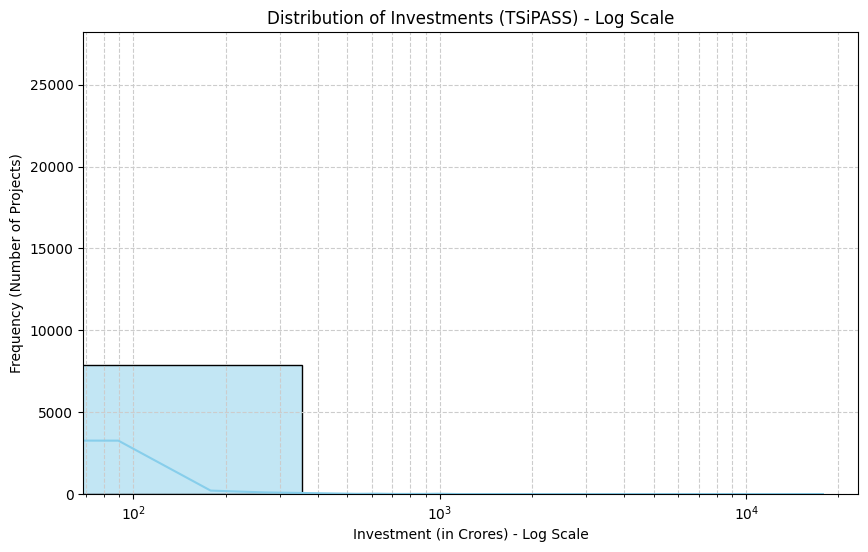

In [7]:
# https://stackoverflow.com/a/1183415

# Plotting the distribution of Investment
# Using log scale for x-axis, to make smaller investments more visible

plt.figure(figsize = (10, 6))
sns.histplot(ipass_DF['Investment'], bins = 50, kde = True, color = 'skyblue')
plt.title('Distribution of Investments (TSiPASS) - Log Scale')
plt.xlabel('Investment (in Crores) - Log Scale')
plt.ylabel('Frequency (Number of Projects)')
plt.xscale('log')
plt.grid(True, which = 'both', ls = '--', c = '.8')
plt.show()

**Observation**

- The graph is heavily skewed to the right, showing that the majority of investments are small (under 10 Crores).
- The highest frequency of projects is for investments between 0.1 and 1 Crore.

In [8]:
# Analyze the quantile distribution of Investment

print('>>> TSiPASS Investment quantile variation\n')
for quantile in np.arange(0.1, 0.99, 0.1):
    print(f'{int(quantile * 100):02} percentile : {round(ipass_DF['Investment'].quantile(quantile), 2):.2f} Cr')
print()
for quantile in np.arange(0.91, 1.001, 0.01):
    print(f'{quantile * 100:.1f} percentile : {round(ipass_DF['Investment'].quantile(quantile), 3):.3f} Cr')
print()
for quantile in np.arange(0.991, 1.001, 0.001):
    print(f'{quantile * 100:.1f} percentile : {round(ipass_DF['Investment'].quantile(quantile), 3):.3f} Cr')

>>> TSiPASS Investment quantile variation

10 percentile : 0.10 Cr
20 percentile : 0.19 Cr
30 percentile : 0.25 Cr
40 percentile : 0.46 Cr
50 percentile : 0.77 Cr
60 percentile : 1.25 Cr
70 percentile : 2.30 Cr
80 percentile : 4.58 Cr
90 percentile : 11.79 Cr

91.0 percentile : 13.474 Cr
92.0 percentile : 15.576 Cr
93.0 percentile : 19.202 Cr
94.0 percentile : 24.506 Cr
95.0 percentile : 31.580 Cr
96.0 percentile : 44.285 Cr
97.0 percentile : 65.042 Cr
98.0 percentile : 115.367 Cr
99.0 percentile : 248.066 Cr
100.0 percentile : 17793.351 Cr

99.1 percentile : 275.849 Cr
99.2 percentile : 327.877 Cr
99.3 percentile : 352.409 Cr
99.4 percentile : 403.145 Cr
99.5 percentile : 486.947 Cr
99.6 percentile : 606.052 Cr
99.7 percentile : 862.121 Cr
99.8 percentile : 1005.056 Cr
99.9 percentile : 1519.118 Cr
100.0 percentile : 17793.351 Cr


In [9]:
# Define new bins for investment categories
# To analyze project counts vs. total impact
# To define small scale investments more accurately

bins = [0, 0.1, 0.5, 1, 5, 10, 50, 100, 500, ipass_DF['Investment'].max() + 1]
labels = ['< 0.1 Cr', '0.1 - 0.5 Cr', '0.5 - 1 Cr', '1 - 5 Cr', '5 - 10 Cr',
          '10 - 50 Cr', '50 - 100 Cr', '100 - 500 Cr', '> 500 Cr']
ipass_DF['Investment_Category'] = pd.cut(ipass_DF['Investment'], bins = bins,
                                         labels = labels, right = False, include_lowest = True)
ipass_DF.sample(3)

,Month,District_Name,Sector,Investment,Number_Of_Employees,social_status_General,social_status_OBC,social_status_SC_ST,Investment_Category
2584,2021-01-01,Bhadradri Kothagudem,Plastic and Rubber,4.20,25,1,0,0,1 - 5 Cr
565,2019-07-01,Jagtial,Agro based incl Cold Storages,0.27,7,0,2,0,0.1 - 0.5 Cr
6187,2023-06-01,Hanumakonda,Others,2.13,20,0,1,0,1 - 5 Cr


In [10]:
# Aggregate data by investment category

investment_category_summary = ipass_DF.groupby('Investment_Category', observed = False).\
                                agg(Total_Investment = ('Investment', 'sum'),
                                    Num_Projects=('Investment', 'count'),
                                    Total_Employees=('Number_Of_Employees', 'sum')).\
                                reset_index().sort_values('Num_Projects', ascending = False)

print('>>> Investment Category Summary\n')
investment_category_summary.head(10)

>>> Investment Category Summary



,Investment_Category,Total_Investment,Num_Projects,Total_Employees
1,0.1 - 0.5 Cr,619.2987,2560,30271
3,1 - 5 Cr,4888.5064,2050,78750
2,0.5 - 1 Cr,817.3919,1119,23983
0,< 0.1 Cr,39.1515,735,78700
5,10 - 50 Cr,12577.6864,603,114964
4,5 - 10 Cr,4041.4429,582,48520
7,100 - 500 Cr,29196.2308,138,199497
6,50 - 100 Cr,8093.2586,117,40493
8,> 500 Cr,66485.7277,40,95195


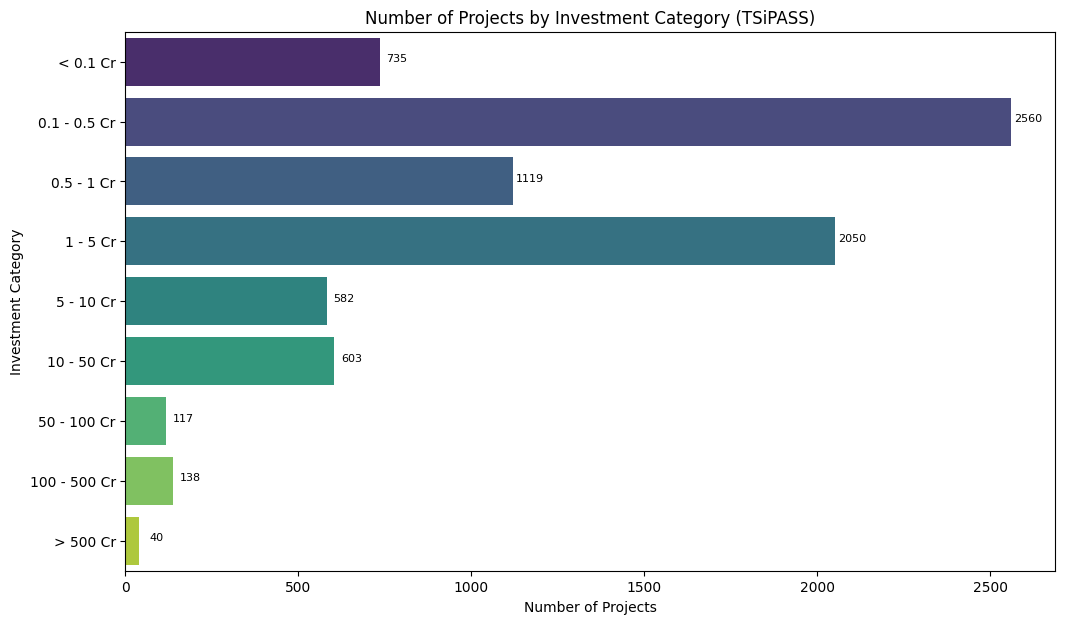

In [11]:
# Plot Number of Projects by Investment Category

plt.figure(figsize = (12, 7))
ax = sns.barplot(investment_category_summary, x = 'Num_Projects', y = 'Investment_Category',
                 hue = 'Investment_Category', palette = 'viridis')

for p in ax.patches:
    ax.text(p.get_width() + 50, p.get_y() + p.get_height() / 2,  f'{int(p.get_width())}',
            horizontalalignment = 'center', size = 8)
 
plt.title('Number of Projects by Investment Category (TSiPASS)')
plt.xlabel('Number of Projects')
plt.ylabel('Investment Category')
plt.show()

**Observation**

- The `0.1 - 0.5 Cr` and `1 - 5 Cr` investment categories contain the highest number of projects.
- As the investment size increases, the number of approved projects generally decreases.
- Projects with investments under 1 Crore make up the majority of all enterprises.
- This plot shows the dominance of MSMEs (Micro, Small & Medium Enterprises).

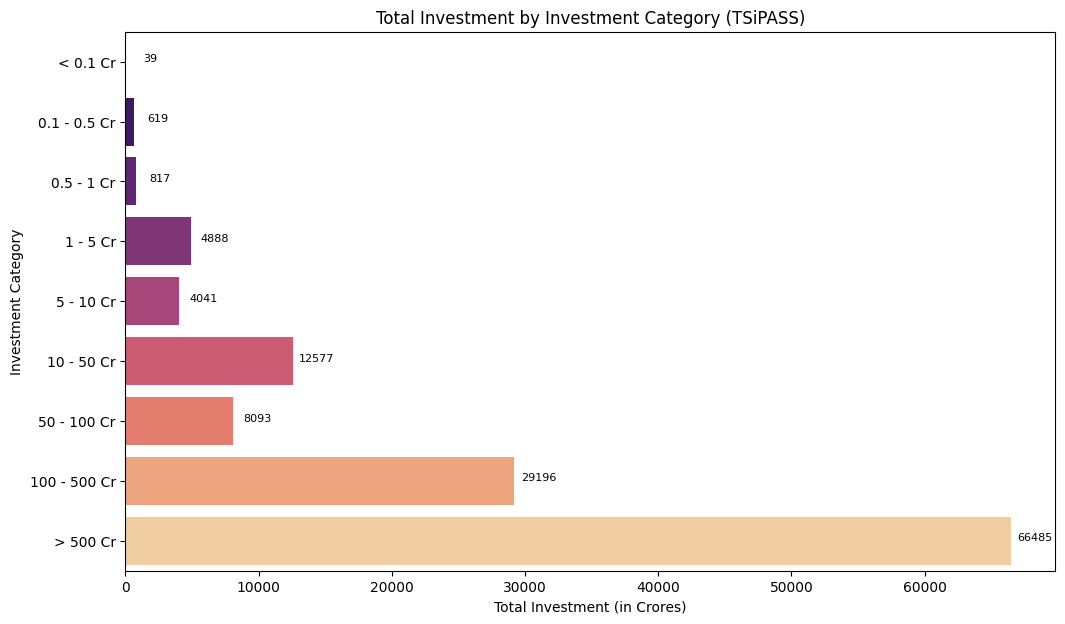

In [12]:
# Plot Total Investment by Investment Category

plt.figure(figsize = (12, 7))
ax = sns.barplot(investment_category_summary, x = 'Total_Investment', y = 'Investment_Category',
                 hue = 'Investment_Category', palette = 'magma')
for p in ax.patches:
    ax.text(p.get_width() + 1800, p.get_y() + p.get_height() / 2,  f'{int(p.get_width())}',
            horizontalalignment = 'center', size = 8)
    
plt.title('Total Investment by Investment Category (TSiPASS)')
plt.xlabel('Total Investment (in Crores)')
plt.ylabel('Investment Category')
plt.show()

**Observation**

- The `> 500 Cr` category contributes the most capital, exceeding 60,000 Crores, despite having the smallest number of projects.
- Chart clearly shows a small number of large-scale investments are responsible for the majority of the total capital inflow.
- The `0.1 - 0.5 Cr` category, with the most projects, accounts for only 619 Crores in total investment.

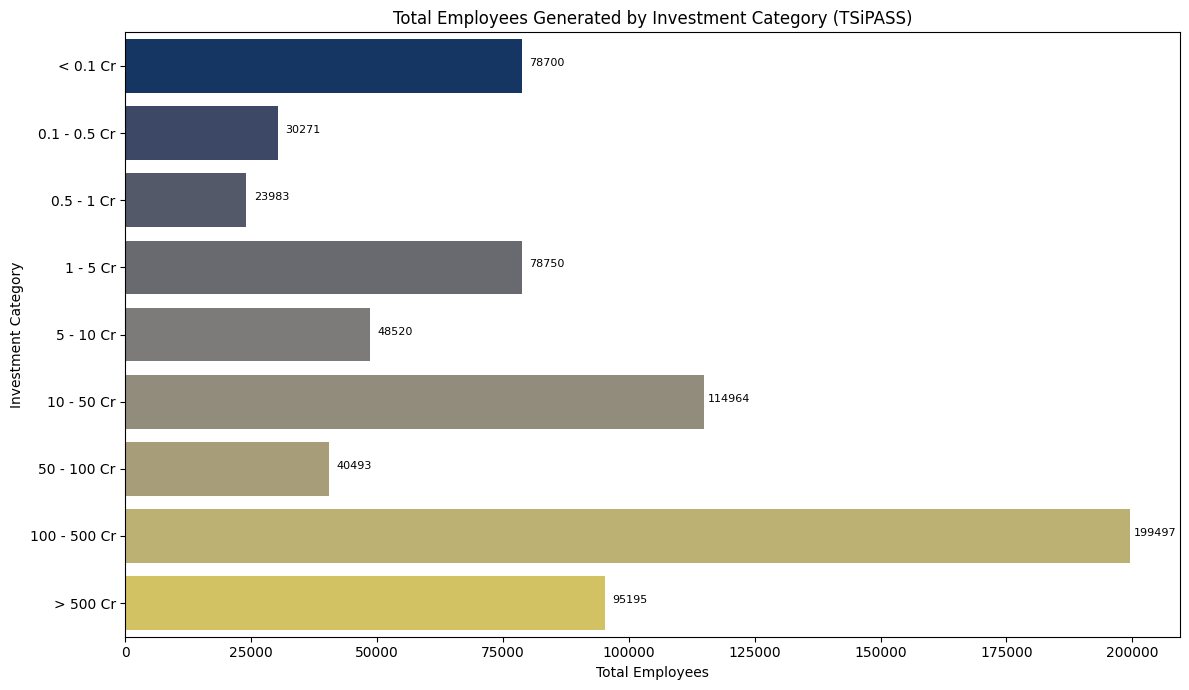

In [13]:
# Plot Total Employees by Investment Category

plt.figure(figsize = (12, 7))
ax = sns.barplot(investment_category_summary, x = 'Total_Employees', y = 'Investment_Category',
                 hue = 'Investment_Category', palette = 'cividis')

for p in ax.patches:
    ax.text(p.get_width() + 5000, p.get_y() + p.get_height() / 2,  f'{int(p.get_width())}',
            horizontalalignment = 'center', size = 8)
    
plt.title('Total Employees Generated by Investment Category (TSiPASS)')
plt.xlabel('Total Employees')
plt.ylabel('Investment Category')
plt.tight_layout()
plt.show()

**Observation**
  
- The `100 - 500 Cr` investment category is expected to create the largest number of jobs, at nearly 200,000.
- The smallest investment category, `< 0.1 Cr`, generates a large number of jobs relative to its low total investment.
- The largest investments (`> 500 Cr`) are not the biggest job creators when compared to the `100 - 500 Cr` category.

In [14]:
ipass_DF_OG = pd.read_parquet('Data/interim/TSiPASS_Data.parquet', engine = 'pyarrow')

original_size = ipass_DF_OG.shape
missingCount = sum(ipass_DF_OG.isnull().sum())
print(f'Number of Districts in TS-iPASS Dataset\t\t: {ipass_DF_OG.District_Name.nunique()}')
print(f'Number of data points in the TS-iPASS Dataset\t: {original_size[0]}')
print(f'Number of missing values in the dataset\t\t: {missingCount}\n')

Number of Districts in TS-iPASS Dataset		: 33
Number of data points in the TS-iPASS Dataset	: 18000
Number of missing values in the dataset		: 0



In [15]:
ipass_DF_OG = ipass_DF_OG.query('Approval_Date < 2025') \
                   .sort_values('Approval_Date').reset_index(drop = True)

filtered_size = ipass_DF_OG.shape

print(f'Number of data points in orginal TS-iPASS Dataset  : {original_size[0]}')
print(f'Number of data points in filtered TS-iPASS Dataset : {filtered_size[0]}')

Number of data points in orginal TS-iPASS Dataset  : 18000
Number of data points in filtered TS-iPASS Dataset : 17949


In [16]:
ipass_DF_OG.Social_Status = ipass_DF_OG.Social_Status.apply(lambda x : re.sub(r'SC|ST', 'SC_ST', x))

# Creatign new feature : Approval Delay
ipass_DF_OG['Approval_Delay'] = ipass_DF_OG.Approval_Date - ipass_DF_OG.Application_Date
ipass_DF_OG.Approval_Delay = ipass_DF_OG.Approval_Delay.dt.days

# Removing unwanted columns
dropCols = ['Name_Of_The_Unit', 'Application_Date', 'Approval_Date',
            'Line_Of_Activity', 'Progress_Of_Implementation']
ipass_DF_OG = ipass_DF_OG.drop(dropCols, axis = 1)

ipass_DF_OG.head()

,District_Name,Sector,Investment,Number_Of_Employees,Social_Status,Approval_Delay
0,Mancherial,Engineering,1.0338,20,OBC,1
1,Kamareddy,Food Processing,0.0400,5,OBC,5
2,Medchal-Malkajgiri,Engineering,0.1100,5,General,0
3,Kamareddy,"Cement, Cement & Concrete Products, Fly Ash Br...",2.4851,15,General,5
4,Medchal-Malkajgiri,Paper and Printing,0.6000,20,General,1


In [17]:
print('>>> Descriptive statistics : Approval Delay (in days)\n')
display(ipass_DF_OG.Approval_Delay.describe())

>>> Descriptive statistics : Approval Delay (in days)



count    17949.000000
mean        37.932977
std        101.235367
min          0.000000
25%          8.000000
50%         13.000000
75%         27.000000
max       1820.000000
Name: Approval_Delay, dtype: float64

In [18]:
if not ipass_DF_OG.query('Approval_Delay < 0').empty:
    print('Found applications with negative approval delays')
    # Removing invalid entries
    ipass_DF = ipass_DF.query('Approval_Delay >= 0')

In [19]:
bins = [0, 0.1, 0.5, 1, 5, 10, 50, 100, 500, ipass_DF_OG['Investment'].max() + 1]
labels = ['< 0.1 Cr', '0.1 - 0.5 Cr', '0.5 - 1 Cr', '1 - 5 Cr', '5 - 10 Cr',
          '10 - 50 Cr', '50 - 100 Cr', '100 - 500 Cr', '> 500 Cr']
ipass_DF_OG['Investment_Category'] = pd.cut(ipass_DF_OG.Investment, bins = bins,
                                         labels = labels, right = False, include_lowest = True)

In [20]:
# Aggregate Approval_Delay by investment category

delay_by_investment = ipass_DF_OG.groupby('Investment_Category', observed = False).\
                                    agg(mean = ('Approval_Delay', 'mean'),
                                    count=('Approval_Delay', 'count')).\
                                    reset_index().sort_values('mean',
                                    ascending = False).reset_index(drop = True)

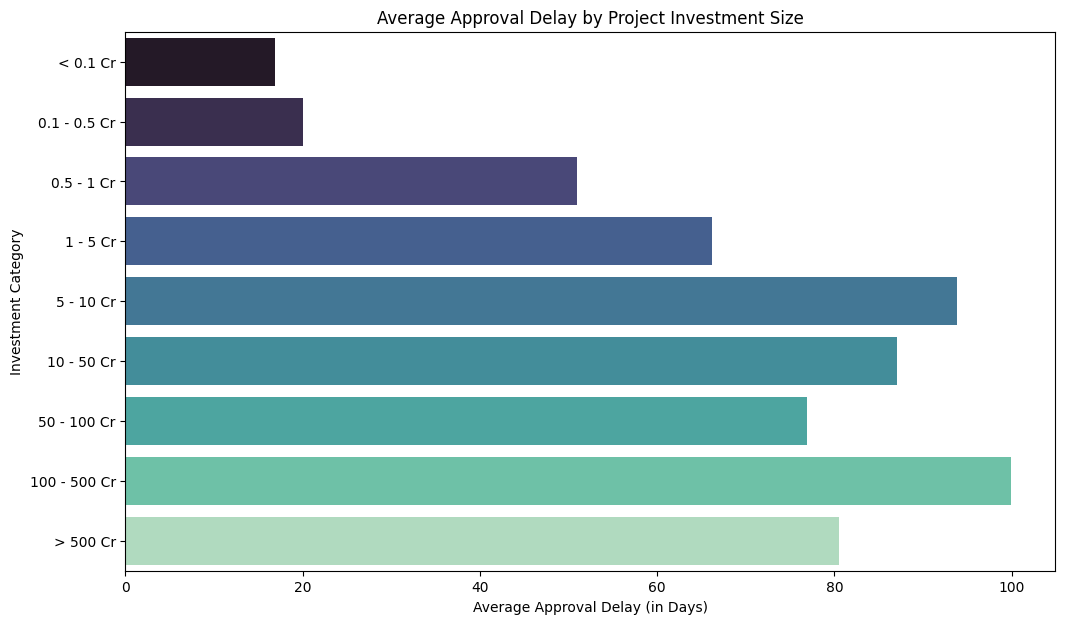

In [21]:
# Plot Average Approval Delay by Project Investment Size

plt.figure(figsize = (12, 7))
sns.barplot(delay_by_investment, x = 'mean', y = 'Investment_Category',
            hue = 'Investment_Category', palette = 'mako')

plt.title('Average Approval Delay by Project Investment Size')
plt.xlabel('Average Approval Delay (in Days)')
plt.ylabel('Investment Category')
plt.show()

**Observation**

- Projects with very small (`< 0.1 Cr`) have lowest average approval delays while very large (`> 500 Cr`) investments face the longest average approval delays.
- Mid-range investments, those between `0.5 - 1 Cr` and `5 - 10 Cr`, have the shortest average delays.
- Comparing categories, smaller investments does't faces longest approval delays, as larger categories.

In [22]:
# Aggregate Approval_Delay by Sector

delay_by_sector = ipass_DF_OG.groupby('Sector', observed = False).\
                                    agg(mean = ('Approval_Delay', 'mean'),
                                    count=('Approval_Delay', 'count')).\
                                    reset_index().sort_values('mean',
                                    ascending = False).reset_index(drop = True)

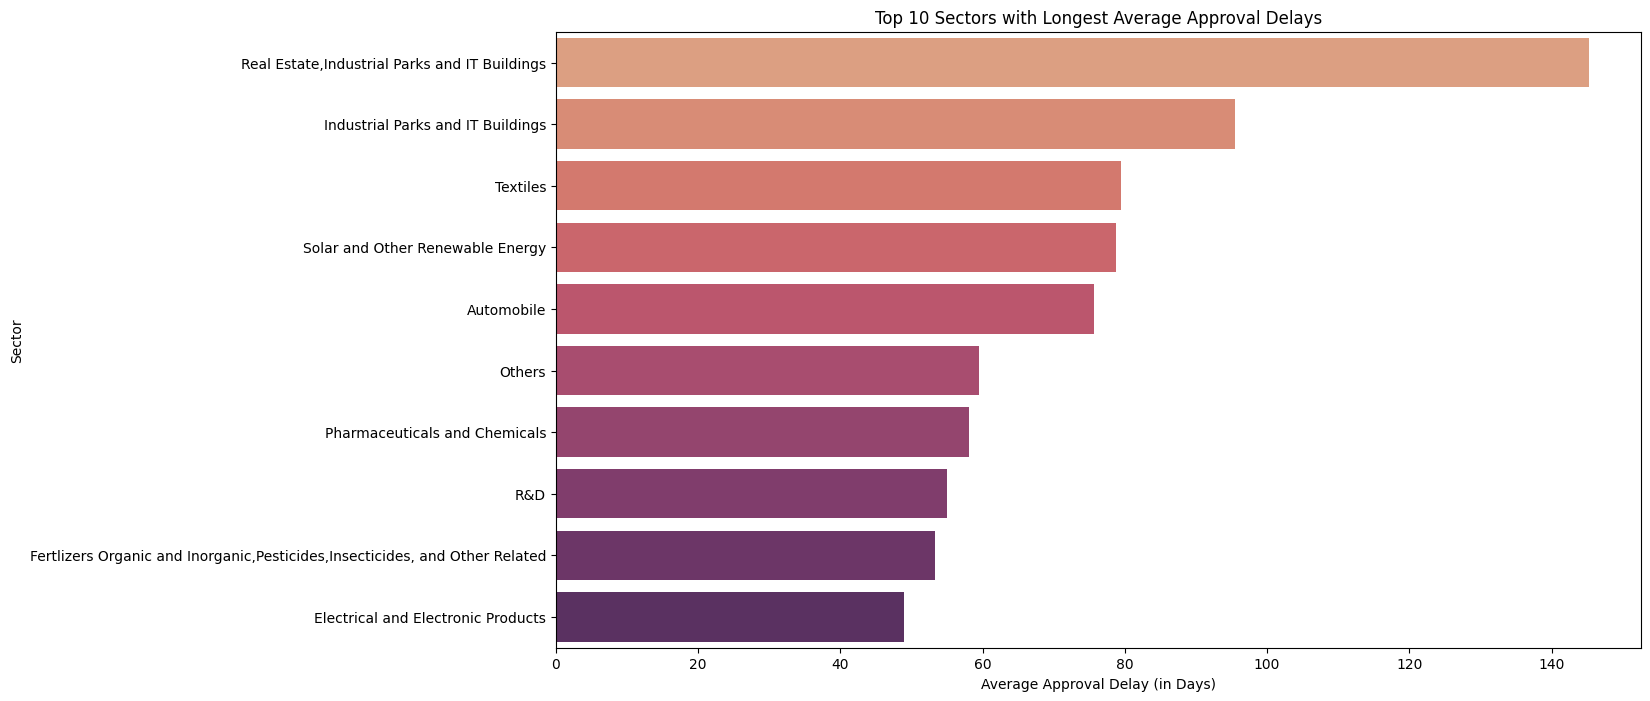

In [23]:
# Plotting top Sectors with Longest Average Approval Delays

plt.figure(figsize = (14, 8))
sns.barplot(delay_by_sector.head(10), x = 'mean', y = 'Sector',
            hue = 'Sector',  palette = 'flare')

plt.title('Top 10 Sectors with Longest Average Approval Delays')
plt.xlabel('Average Approval Delay (in Days)')
plt.ylabel('Sector')
plt.show()

**Observation**

- The 'Industrial Area Development' sector has the longest average approval delays, averaging over 100 days.
- 'Pharmaceuticals and Chemicals' and 'Solar and Other Renewable Energy' sectors also faces approval time exceeding 60 days on average
- Among the top ten, 'Electrical and Electronic Products' has the shortest average delay, at approximately 50 days.

In [24]:
# Aggregate Approval_Delay by Sector

delay_by_social_status = ipass_DF_OG.groupby('Social_Status', observed = False).\
                                    agg(mean = ('Approval_Delay', 'mean'),
                                    count=('Approval_Delay', 'count')).\
                                    reset_index().sort_values('mean',
                                    ascending = False).reset_index(drop = True)

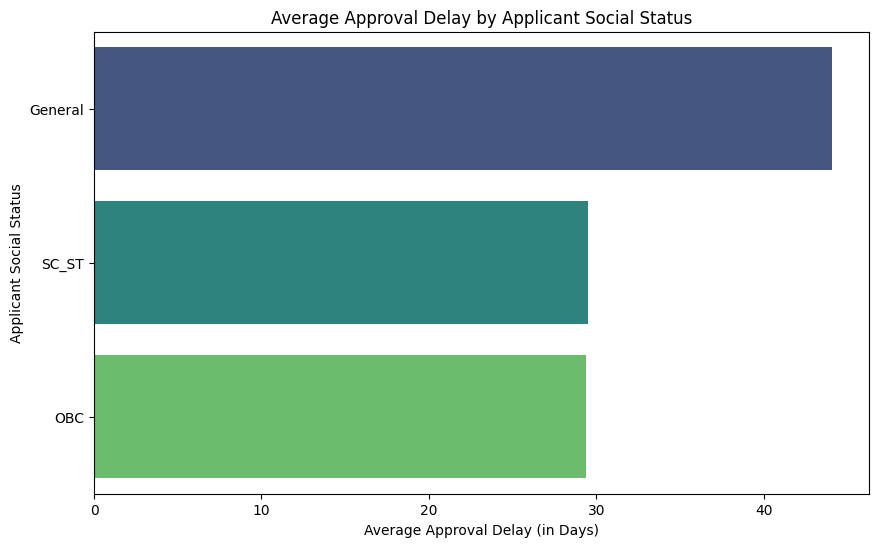

In [25]:
# Plotting Average Approval Delay by Applicant Social Status

plt.figure(figsize = (10, 6))
sns.barplot(delay_by_social_status, x = 'mean', y = 'Social_Status',
            hue = 'Social_Status', palette = 'viridis')

plt.title('Average Approval Delay by Applicant Social Status')
plt.xlabel('Average Approval Delay (in Days)')
plt.ylabel('Applicant Social Status')
plt.show()

**Observation**

- Applicants from the 'General' category now face the longest average approval delays, at approximately 40+ days.
- Applicants from the 'OBC' and 'SC_ST' categories experience much shorter and almost identical delays of about 30 days.
- 'General' also submits the highest number of applications, and have longest average waiting period for approvals.
- This clearly indicates no one is having an unfare advantage on the approval time.

In [26]:
# Aggregate Approval_Delay by Sector

scst_projects = ipass_DF_OG.query('Social_Status == "SC_ST"').copy(deep = True)

scst_delay_by_sector = scst_projects.groupby('Sector', observed = False).\
                                    agg(mean = ('Approval_Delay', 'mean'),
                                    count=('Approval_Delay', 'count')).\
                                    reset_index().sort_values('mean',
                                    ascending = False).reset_index(drop = True)

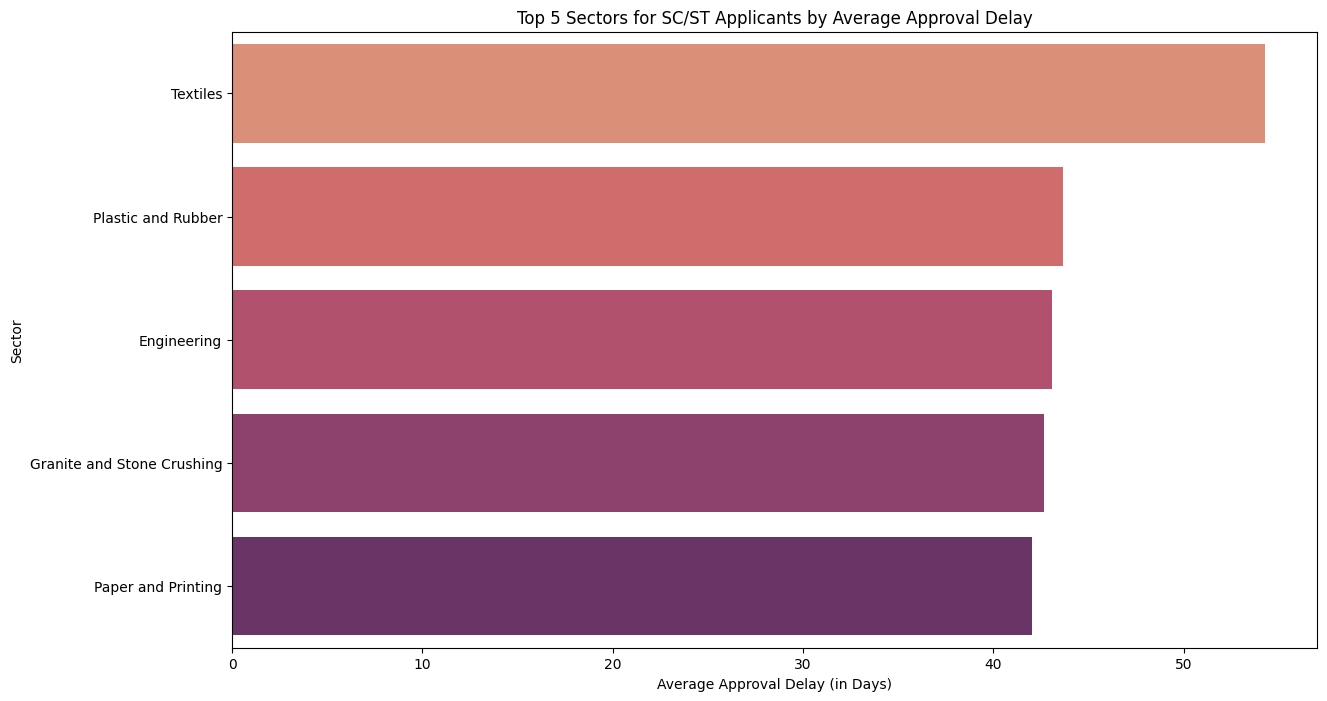

In [27]:
# Plotting top Sectors with Longest Average Approval Delays

plt.figure(figsize = (14, 8))
sns.barplot(scst_delay_by_sector.head(5), x = 'mean', y = 'Sector',
                hue = 'Sector',  palette = 'flare')

plt.title('Top 5 Sectors for SC/ST Applicants by Average Approval Delay')
plt.xlabel('Average Approval Delay (in Days)')
plt.ylabel('Sector')
plt.show()

**Observation**

- Most projects are small investments under 5 Crores. However, a few large-scale ventures contribute the majority of the total capital investment.
- Job creation does not directly scale with investment size. While the '100-500 Cr' category creates the most jobs, the smallest ventures are also highly labor-intensive.
- Approval delays increase with investment size, ranging from ~17 days for the smallest projects to nearly 80+ days for larger categories.
- Approval timelines changes by sector. 'Industrial Area Development' faces the longest average delays, showing industry type is a key factor.
- 'General' category applicants face the longest average delays, while 'OBC' and 'SC/ST' applicants experience much shorter wait times.

### Justification for the Problem Statement

- Contrary to the initial problem statement, the smallest investment projects (under 0.1 Cr) actually experience the shortest average approval delays, at approximately 17 days.
- The significant approval delays are observed for larger investments, particularly in the '100 - 500 Cr' category, whose average is  nearly 100 days for approval.
- While the smallest projects have quicker approvals, they still represent a substantial volume of applications, with the '0.1 - 0.5 Cr' category having the highest project count.
- While SC/ST applicants approvals are faster on average (~30 days), they face extreme sector-specific delays, such as over 50 days in the 'Textiles' industry.

## Problem Statement - 2

**e-Stamp adoption efficiency over document registration :** Identify if digital transitions in registrations improved revenue collection efficiency for scalable governance and promoting digital inclusion.

In [28]:
# Aggregate monthly totals for documents, revenue and e-stamps

monthly_reg_summary = registration_DF.groupby(registration_DF['Month'].dt.to_period('M')).\
                      agg(Total_Documents_Registered=('Documents_Registered_Cnt', 'sum'),
                          Total_Revenue=('Documents_Registered_Rev', 'sum'),
                          Total_Estamps_Cnt=('Estamps_Challans_Cnt', 'sum'),
                          Total_Estamps_Rev=('Estamps_Challans_Rev', 'sum')).reset_index()

# Convert back to timestamp for plotting
monthly_reg_summary['Month'] = monthly_reg_summary['Month'].dt.to_timestamp()

In [29]:
# Calculate percentages for e-stamp adoption

monthly_reg_summary['Estamp_Cnt_Share'] = monthly_reg_summary['Total_Estamps_Cnt'].\
                                    div(monthly_reg_summary['Total_Documents_Registered']) * 100

monthly_reg_summary['Estamp_Rev_Share'] = monthly_reg_summary['Total_Estamps_Rev'].\
                                    div(monthly_reg_summary['Total_Revenue']) * 100

# monthly_reg_summary.fillna(0, inplace=True)

In [30]:
print('>>> Monthly E-Stamp Adoption Share\n')
monthly_reg_summary.sample(5)

>>> Monthly E-Stamp Adoption Share



,Month,Total_Documents_Registered,Total_Revenue,Total_Estamps_Cnt,Total_Estamps_Rev,Estamp_Cnt_Share,Estamp_Rev_Share
57,2023-11-01,78839,9001897814,81389,9028712056,103.234440,100.297873
4,2019-05-01,144201,5690714330,0,0,0.000000,0.000000
24,2021-01-01,147889,8026290644,153097,7945228351,103.521560,98.990040
19,2020-08-01,104469,3814722471,0,0,0.000000,0.000000
61,2024-03-01,105490,10315765157,109672,10452786252,103.964357,101.328269


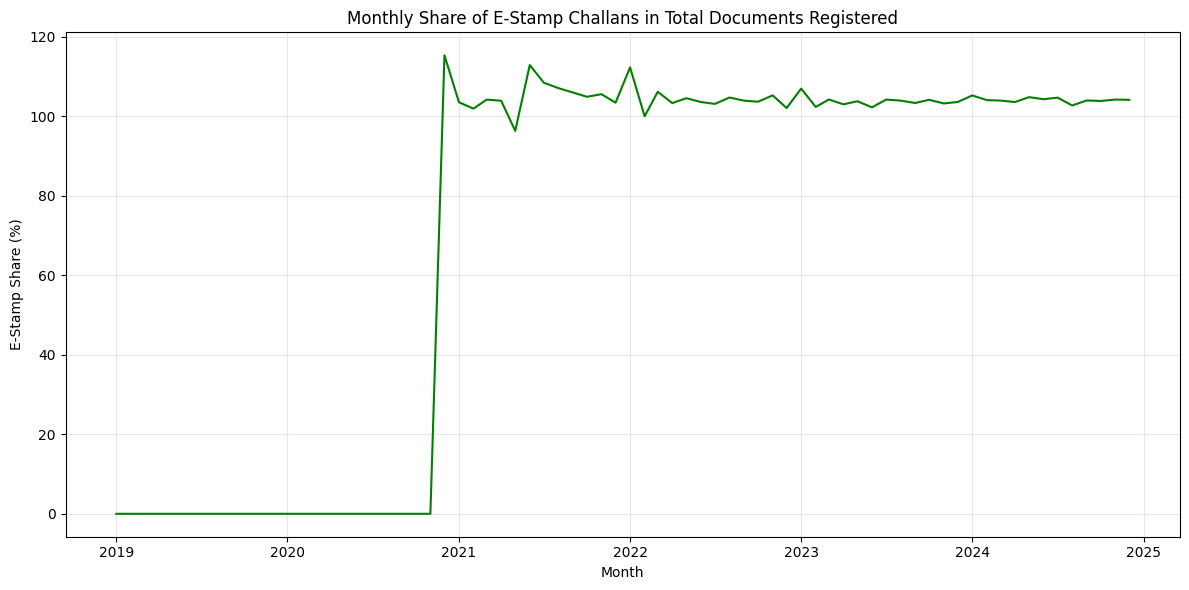

In [31]:
# Plot Monthly E-Stamp Count Share

plt.figure(figsize = (12, 6))
sns.lineplot(monthly_reg_summary, x = 'Month', y = 'Estamp_Cnt_Share', color = 'green')
plt.title('Monthly Share of E-Stamp Challans in Total Documents Registered')
plt.xlabel('Month')
plt.ylabel('E-Stamp Share (%)')
plt.grid(True, c = '0.9')
plt.tight_layout()
plt.show()

**Observation**

- Plot shows clearly that there was zero adoption of e-stamps before the late 2020.
- This exponential grown indicates post COVID eras push for digital transition and states intervention to stop cash transaction to create proper accountability.
- A very rapid addaption to e-stamps occurred from late 2020 through 2021, with the share quickly rising to nearly 100%.
- The e-stamps share consistently remained close to 100% since 2022, showing the number of e-stamp challans issued per month now is higher.

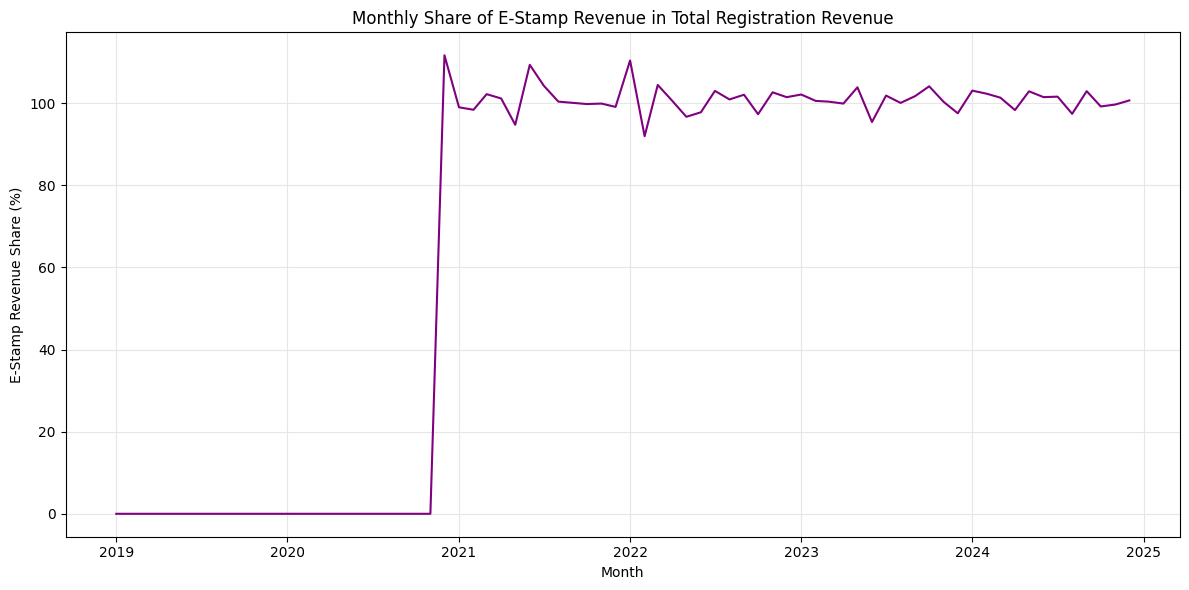

In [32]:
# Plot Monthly E-Stamp Revenue Share

plt.figure(figsize = (12, 6))
sns.lineplot(data = monthly_reg_summary, x = 'Month', y = 'Estamp_Rev_Share', color = 'purple')
plt.title('Monthly Share of E-Stamp Revenue in Total Registration Revenue')
plt.xlabel('Month')
plt.ylabel('E-Stamp Revenue Share (%)')
plt.grid(True,c = '0.9')
plt.tight_layout()
plt.show()

**Observation**

- Similar to the challan count, the revenue from e-stamps was zero before late 2020.
- As earlier mentioned, this is be due to post COVID and government rule changes.
- The change in revenue collection to the e-stamp system was fast and complete, rising from 0% to nearly 100% in an year.
- From 2022, e-stamp revenue has consistently high for nearly all registration revenue, showing a successful transition to digital system.

In [33]:
# Overall E-Stamp Adoption (across the entire dataset)

overall_estamps_cnt = monthly_reg_summary['Total_Estamps_Cnt'].sum()
overall_total_documents = monthly_reg_summary['Total_Documents_Registered'].sum()
overall_estamps_rev = monthly_reg_summary['Total_Estamps_Rev'].sum()
overall_total_revenue = monthly_reg_summary['Total_Revenue'].sum()

overall_estamp_cnt_percent = (overall_estamps_cnt / overall_total_documents) * 100
overall_estamp_rev_percent = (overall_estamps_rev / overall_total_revenue) * 100

print(f'Overall E-Stamp Count Share (Across all months)  : {overall_estamp_cnt_percent:.2f}%')
print(f'Overall E-Stamp Revenue Share (Across all months): {overall_estamp_rev_percent:.2f}%')

Overall E-Stamp Count Share (Across all months)  : 68.77%
Overall E-Stamp Revenue Share (Across all months): 82.40%


**Observation**

- Data shows a complete shift to e-stamps.
- Adoption started in late 2020 and reached nearly 100% for both counts and revenue by early 2022.
- Across the entire period, e-stamps make up a majority share:
    - 68.77% of document counts and 82.40% of total revenue, this confirms a successful digital transition.
- The revenue share (82.40%) is higher than the count share (68.77%), which shows e-stamps are more frequently used for higher-value registrations.
- The e-stamp adoption and revenue growth shows improved digital efficiency with scalable governance for future.

### Justification for the Problem Statement

- The analysis is justified as a fast and near-total shift to e-stamps happened from 2020-2022, and it was a major digital transformation.
- The digital transition to e-stamps have been highly successful, with 68.77% of challans and 82.40% of revenue now electronic.
- E-stamps shows improved revenue collection efficiency, accounting a larger share of revenue (82.40%) than document counts (68.77%).
- This fast e-stamp adoption shows scalable governance and digital inclusion, transforming document registration for the state ot fully digital.

## Problem Statement - 3

**Rainfall-mechanization mismatch inflates farm costs :** Uneven rainfall forces over/under investments in agri-vehicles without promising irrigation infrastructure  might lead to unnecessary capital expenditure and subsidies.

In [34]:
def subplot_bar_chart(agri_dataframe: pd.DataFrame, weather_dataframe: pd.DataFrame,
                      year:str = None, HEAD:int = 5, fontsize:int = 12,
                      figsize:tuple[int, int] = (18, 6)):

    # plot settings
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize = figsize)
    plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
    label_font_size = fontsize - 3
    
    # Row 1: Top 5 Districts
    # Subplot 1: Top 5 by Agri Vehicle Sales
    top_agri_districts = agri_dataframe.sort_values('vClass_Agriculture',
                                               ascending = False).head(HEAD)
    sns.barplot(data=top_agri_districts, x = 'vClass_Agriculture', y = 'District',
                hue = 'District', palette = 'viridis', ax = axes[0])
    axes[0].set_title('Top 5 Districts by Agri Vehicle Sales', fontsize = fontsize)
    axes[0].set_xlabel('Total Vehicles Registered', fontsize = label_font_size)
    axes[0].set_ylabel('District')

    # Subplot 2: Top 5 by Average Rainfall
    top_avg_rain_districts = weather_dataframe.sort_values('RainFall',
                                                                  ascending = False).head(HEAD)
    sns.barplot(top_avg_rain_districts, x = 'RainFall', y = 'District',
                hue ='District', palette='Blues_d', ax = axes[1])
    axes[1].set_title('Top 5 Districts by Average Rainfall', fontsize = fontsize)
    axes[1].set_xlabel('Average Rainfall', fontsize = label_font_size)
    axes[1].set_ylabel('')
    
    # Subplot 3: Top 5 by Rainfall Variability
    top_std_rain_districts = weather_dataframe.sort_values('Std_Rainfall',
                                                                  ascending = False).head(HEAD)
    sns.barplot(data=top_std_rain_districts, x = 'Std_Rainfall', y = 'District',
                hue = 'District', palette = 'YlOrRd_r', ax = axes[2])
    axes[2].set_title('Top 5 Districts by Rainfall Variability', fontsize = fontsize)
    axes[2].set_xlabel('Average Std. Dev of Rainfall', fontsize = label_font_size)
    axes[2].set_ylabel('')

    for ax in axes.flat:
        ax.tick_params(axis = 'both', labelsize = label_font_size)

    if not (isinstance(year, int) and 2019 <= year <= 2024):
        year = '2019-2024'
        
    plt.suptitle(
    f'Top {HEAD} Districts: Agriculture Vehicle Registrations and Rainfall Trends : {year}', 
    fontsize = fontsize + 4, fontweight = 'bold', y = 1.02)
    plt.tight_layout()
    plt.show()

In [35]:
def get_district_agri_summary(df: pd.DataFrame, year:int|None = None) -> pd.DataFrame:
    if isinstance(year, int) and 2019 <= year <= 2024:
        return df.query('Year == @year').groupby(
                        'District')['vClass_Agriculture'].agg('sum').reset_index()
    return df.groupby('District')['vClass_Agriculture'].agg('sum').reset_index()

In [36]:
def get_district_weather_summary(df: pd.DataFrame, year:int|None = None) -> pd.DataFrame:
    if isinstance(year, int) and 2019 <= year <= 2024:
        return df.query('Year == @year').groupby(
                        'District')[['RainFall', 'Std_Rainfall']].agg('mean').reset_index()
    return df.groupby('District')[['RainFall', 'Std_Rainfall']].agg('mean').reset_index()

In [37]:
def plot_year_trend_chart(year, head):

    # Aggregate data to a district-wise summary for the entire period
    district_agri_summary = get_district_agri_summary(df = rta_DF, year = year)
    district_weather_summary = get_district_weather_summary(df = Weather_DF,
                                                            year = year)
    subplot_bar_chart(agri_dataframe = district_agri_summary, year = year,
                      weather_dataframe = district_weather_summary,
                      HEAD = head, fontsize = 12)

In [38]:
# Creating 'Year' feature from 'Month'

rta_DF['Year'] = rta_DF['Month'].dt.year
Weather_DF['Year'] = Weather_DF['Month'].dt.year

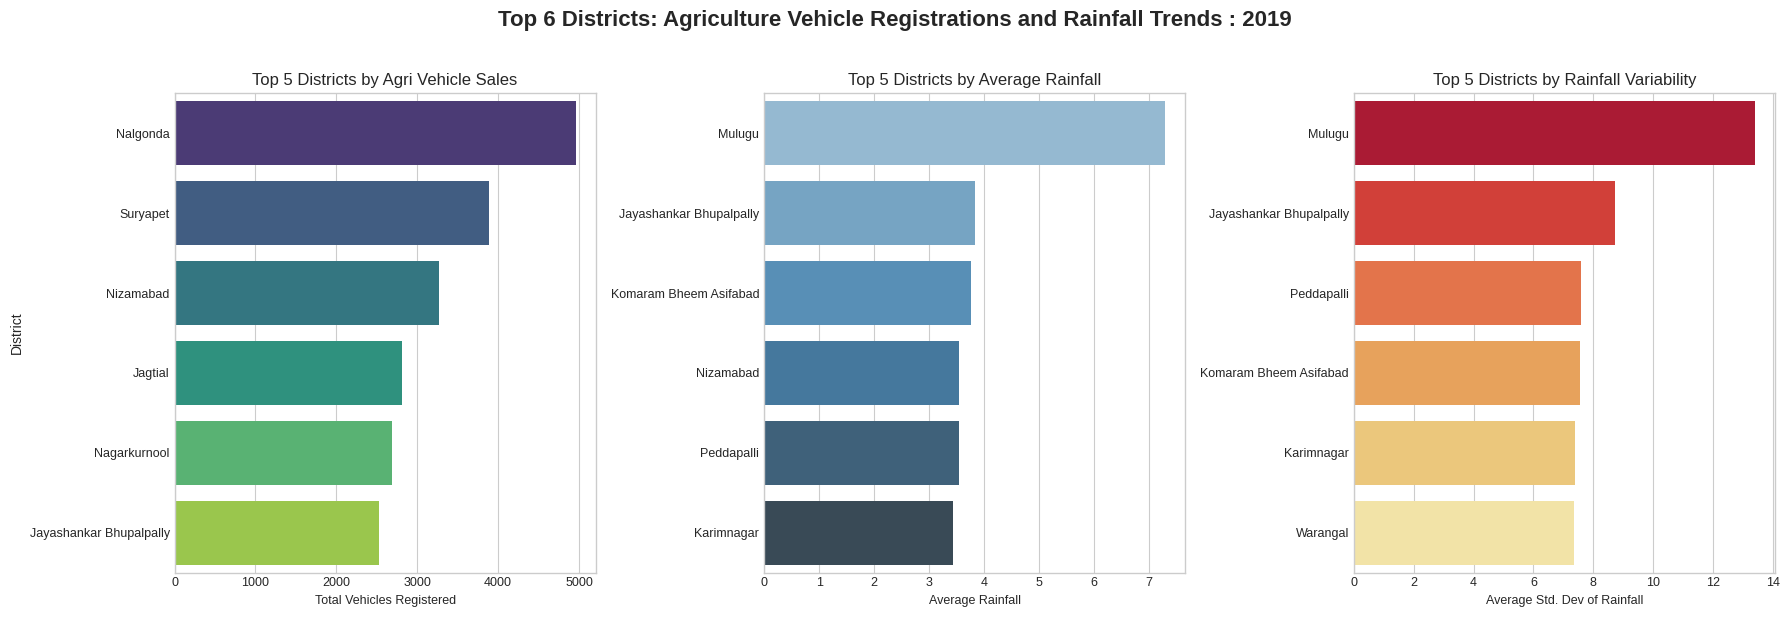

In [39]:
plot_year_trend_chart(year = 2019, head = 6)

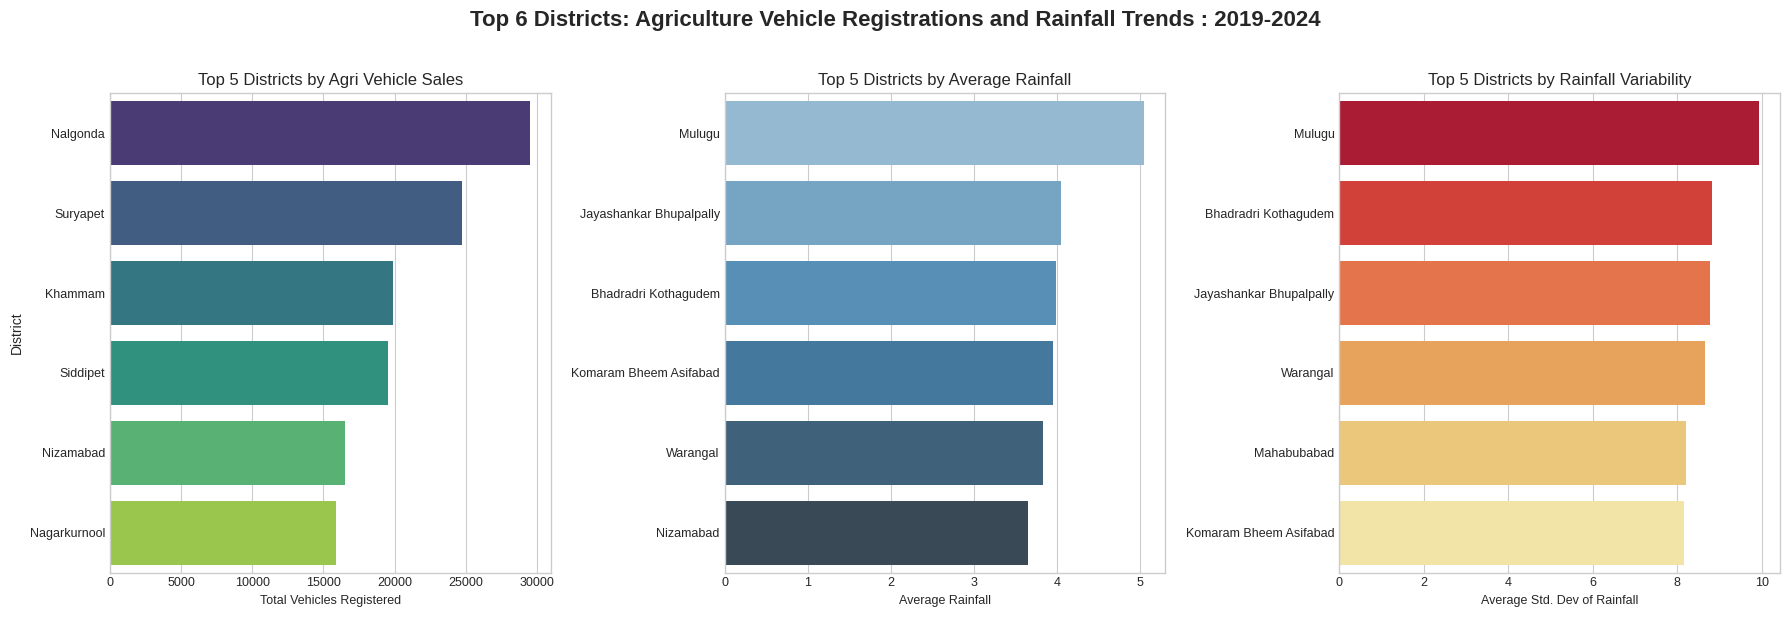

In [40]:
plot_year_trend_chart(year = 'all', head = 6)

**Observations**

- Nalgonda clearly leads in agricultural vehicle sales, ranking as the top district in both 2019 and over the entire 2019-2024 period.
- A clear mismatch exists in all periods, districts leading in vehicle sales are not the one with the highest average rainfall (like Mulugu).
- This mismatch between high mechanization and high rainfall is not occured in a single year, but consistently occured throughout 2019 to 2024.
- Districts like Adilabad and Nirmal having the most unpredictable rainfall, but these does not leads in vehicle sales, showing other factors are also involved in purchasing decisions.
- Suryapet ranks as a top district for vehicle sales in both 2019 and overall period, which shows a concentrated mechanization in specific, non-rainfall-dominant areas.

In [41]:
def plot_sales_ns_rain_variability(year:int = 2024, figsize:tuple[int, int] = (12, 6),
                                   fontsize:int = 10, head = 10):
    if isinstance(year, int) and 2019 <= year <= 2024:
        district_agri_summary = rta_DF.query('Year == @year').groupby('District')\
                                            ['vClass_Agriculture'].agg('sum').reset_index()
        district_weather_summary = Weather_DF.query('Year == @year').groupby('District')\
                                            ['Std_Rainfall'].agg('mean').reset_index()
    else:
        district_agri_summary = rta_DF.groupby('District')['vClass_Agriculture'].\
                                                            agg('sum').reset_index()
        district_weather_summary = Weather_DF.groupby('District')['Std_Rainfall'].\
                                                            agg('mean').reset_index()
        year = '2019-2024'

    merged_summary = pd.merge(district_agri_summary, district_weather_summary,
                              on = 'District', how = 'inner')
    top_agri_districts = merged_summary.sort_values('vClass_Agriculture',
                                            ascending = False).head(head).reset_index(drop = True)

    fig, ax1 = plt.subplots(figsize = figsize)
    
    sns.barplot(top_agri_districts, y = 'District', x = 'vClass_Agriculture',
                hue = 'District', palette = 'viridis', orient = 'h', ax = ax1)
    
    ax1.set_title(
        f'Top {head} Agri-Mechanization Districts: Sales vs. Rainfall Variability : {year}',
        fontsize = fontsize + 2, fontweight = 'bold')
    ax1.set_xlabel('Total Vehicles Registered', fontsize = fontsize,
                                                   color = sns.color_palette('viridis')[0])
    ax1.set_ylabel('District', fontsize = fontsize)
    ax1.tick_params(axis = 'x', colors = sns.color_palette('viridis')[0])
    
    ax2 = ax1.twiny()
    ax2.plot(top_agri_districts['Std_Rainfall'], top_agri_districts['District'],
                                                 color = 'red', marker = 'o', linestyle = '--')
    
    ax2.set_xlabel('Rainfall Variability (Std. Dev)', fontsize = fontsize, color = 'red')
    ax2.tick_params(axis = 'x', colors = 'red')
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, ['Total Agri Vehicles', 'Rainfall Variability'], loc='lower right')
    
    fig.tight_layout()
    plt.show()

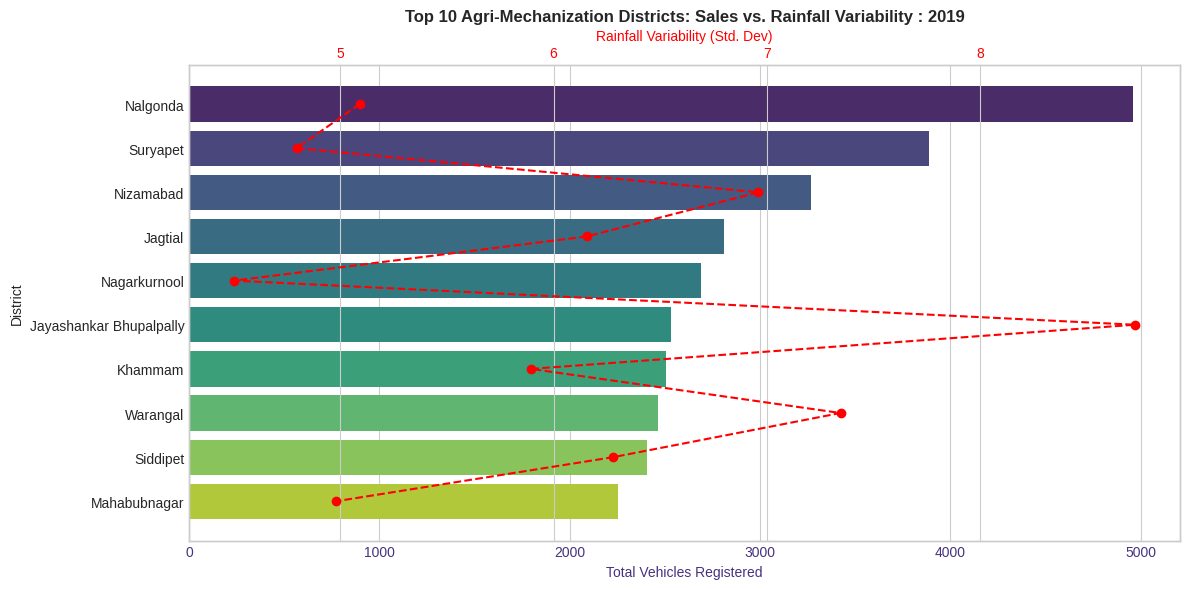

In [42]:
plot_sales_ns_rain_variability(year = 2019)

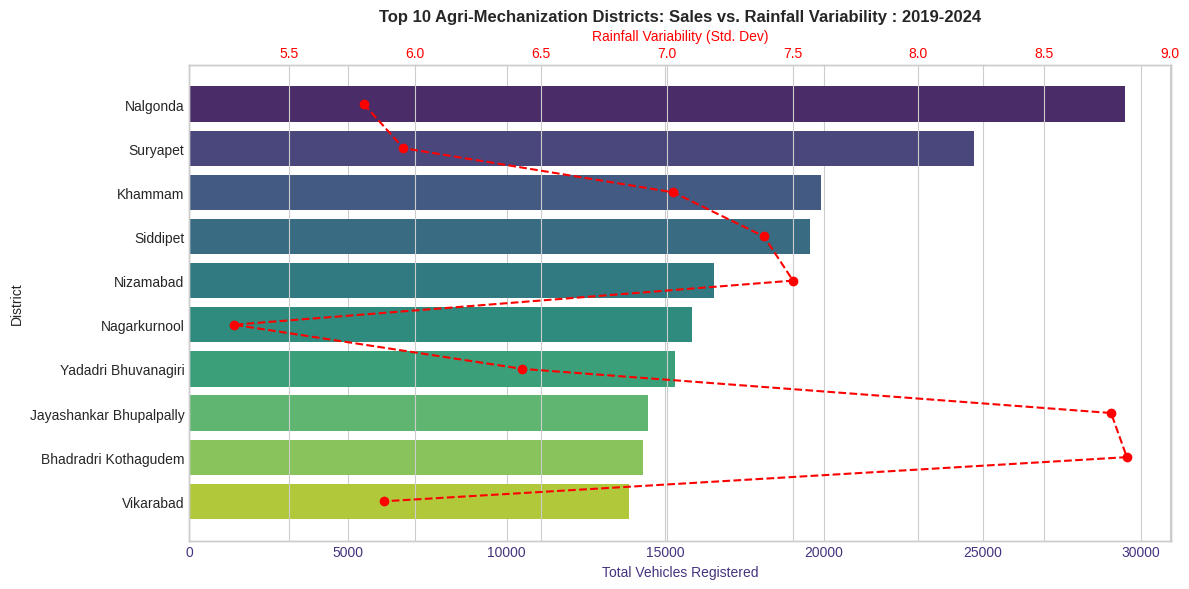

In [43]:
plot_sales_ns_rain_variability(year = 'all')

**Observations**

- The charts shows the relationship between high sales volume and rainfall unpredictability in the most mechanized districts.
- For the 2019 and overall period (2019-2024), Nalgonda is the sales leader, also have one of the lowest rainfall variabilities among top districts, which indicates some correclation in this case.
- However, other districts like Suryapet and Suryapet also showing high sales and lower rain variability. This might be sowing that there is no consistent pattern where high mechanization is always linked to stable rainfall.
- Districts that are having rain variability range `5-7` shows the most vehicle sales, and not are urban districts.
- Districts like Nalgonda and Suryapet were the 2 districts that got recored in the top 15 districts with investment. 

In [44]:
def regression_plot(year:int = 2024, figsize:tuple[int, int] = (12, 8), fontsize:int = 10):

    if isinstance(year, int) and 2019 <= year <= 2024:
        district_agri_summary = rta_DF.query('Year == @year').groupby('District')\
                                            ['vClass_Agriculture'].agg('sum').reset_index()
        district_weather_summary = Weather_DF.query('Year == @year').groupby('District')\
                                            ['Std_Rainfall'].agg('mean').reset_index()
    else:
        district_agri_summary = rta_DF.groupby('District')['vClass_Agriculture'].\
                                                            agg('sum').reset_index()
        district_weather_summary = Weather_DF.groupby('District')['Std_Rainfall'].\
                                                            agg('mean').reset_index()
        year = '2019-2024'

    merged_summary = pd.merge(district_agri_summary, district_weather_summary,
                              on = 'District', how = 'inner')
    
    # https://seaborn.pydata.org/tutorial/regression.html
    # https://www.tutorialspoint.com/seaborn/seaborn_regplot_method.htm    
    plt.figure(figsize = figsize)
    sns.regplot(merged_summary, x = 'Std_Rainfall', y = 'vClass_Agriculture',
                scatter_kws = {'alpha' : 0.7, 's' : 80},
                line_kws = {'color' : 'red', 'linestyle' : '--', 'linewidth' : 2})
    
    # Adjust the text annotations to minimize overlap
    # https://github.com/Phlya/adjustText
    # https://adjusttext.readthedocs.io/en/latest/
    texts = []
    for i, row in merged_summary.iterrows():
        text = plt.text(row['Std_Rainfall'], row['vClass_Agriculture'],
                        row['District'], fontsize = fontsize - 1,
                        ha = 'left', va = 'bottom', alpha = 0.7)
        texts.append(text)
    adjust_text(texts, only_move = {'text' : 'xy'})
    
    plt.title(
        f'Rainfall Variability vs. Agricultural Vehicle Registrations by District : {year}',
        fontsize = fontsize + 2, fontweight = 'bold')
    plt.xlabel('Overall Rainfall Variability (Avg. Std. Dev)', fontsize = fontsize)
    plt.ylabel('Total Agricultural Vehicle Registrations', fontsize = fontsize)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

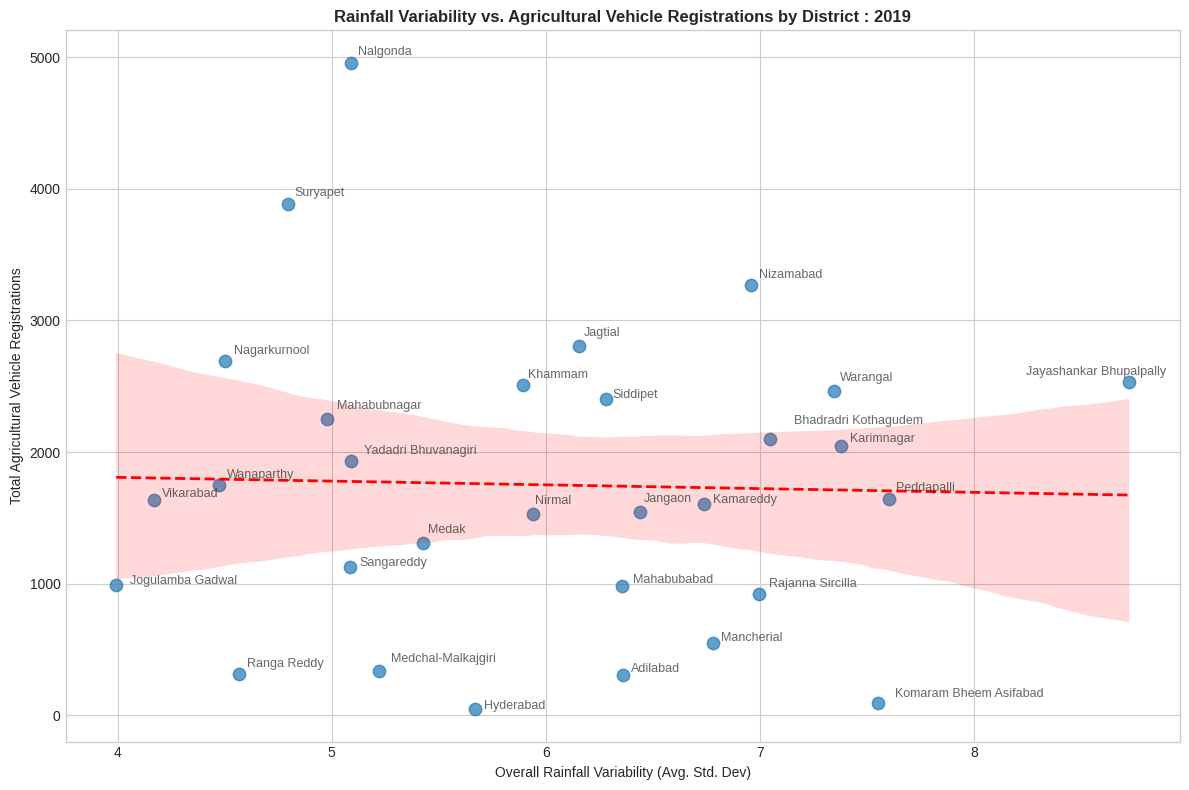

In [45]:
regression_plot(2019)

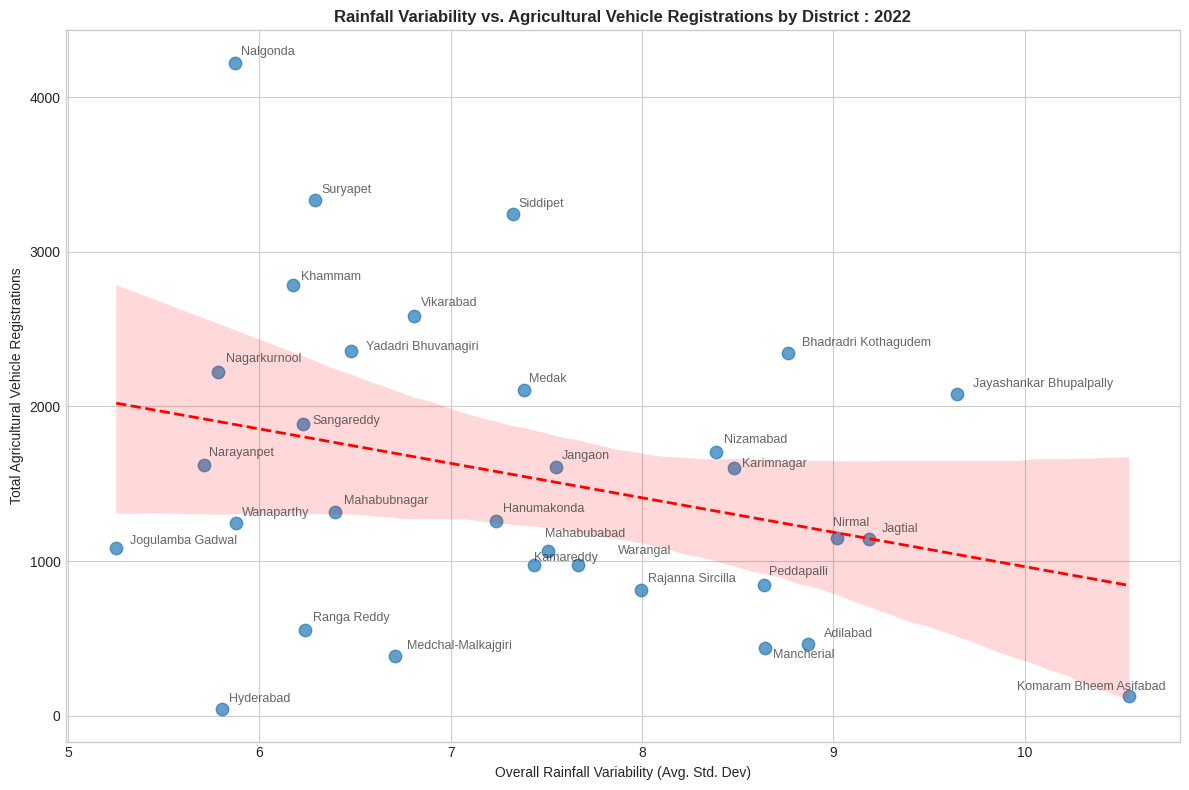

In [46]:
regression_plot(2022)

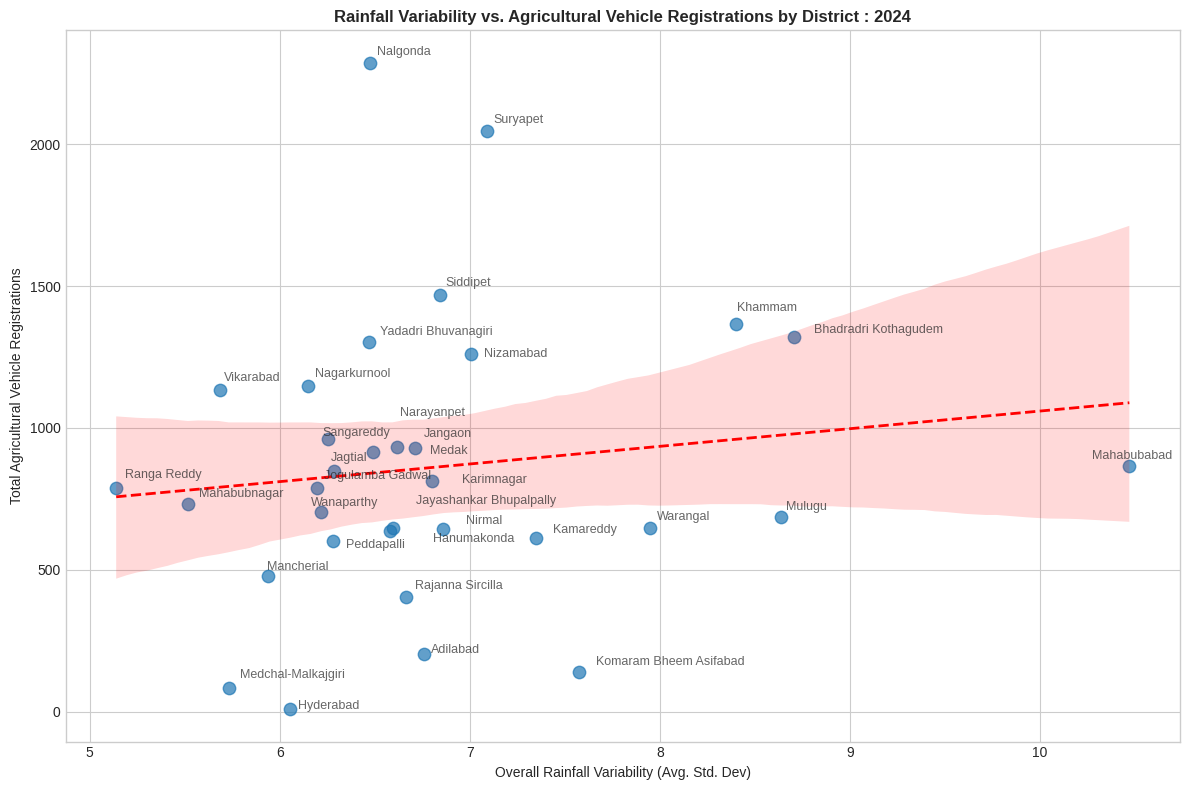

In [47]:
regression_plot(2024)

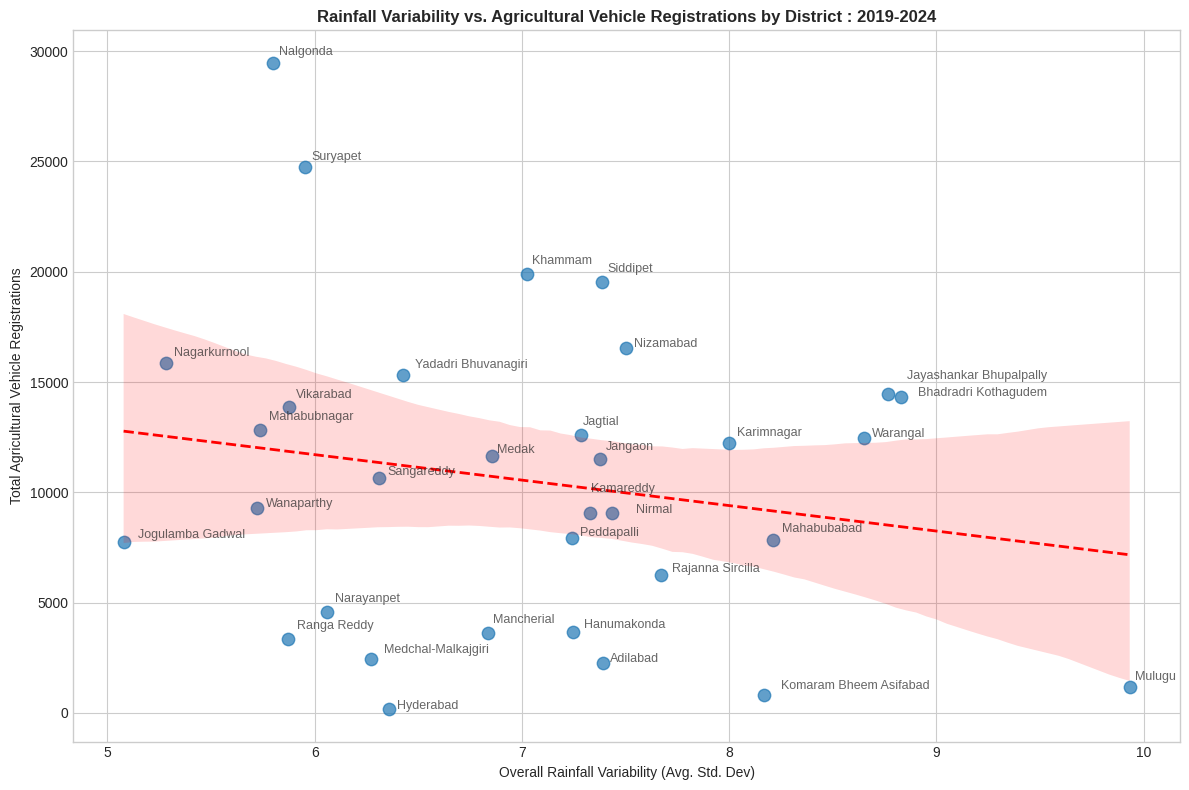

In [48]:
regression_plot('all')

**Observations**

- The plots show a wide spread of districts with no clear pattern, meaning districts with similar rainfall variability can have very different vehicle sales.
- The regression lines are almost flat, showing a very weak or no correlation between rainfall variability and agricultural vehicle sales.
- Districts like Nalgonda and Suryapet stand out with higher vehicle sales, regardless of rainfall variability.
- This shows factors like Government packages, soil type and economic conditions are more important than climate instability in driving farm mechanization.
- As news reports mentioned, this could be due the over-investment and the under returns from  farming.
- Comparing the plots for 2019 and 2024, it's clear that rainfall patterns have changed a lot, and at the same time, agri-vehicle sales have dropped significantly.

### Justification for the Problem Statement

- The analysis confirms a mismatch as there is a very weak correlation between district's rainfall variability and its agricultural vehicle sales.
- The districts with high agri-vehicle sales, like Nalgonda, Suryapet and Siddipet consistently having moderate rainfall variability and getting investments from industries also.
- High vehicle sales in certain districts regardless of their rainfall patterns indicate non-climatic factors might be the primary drivers of mechanization decisions.
- The previous plots of investments in the state with this plot indicating, industries prefer predictable areas as base, and this might push the farming activites in those regions.
- Thus promising irrigation infrastructure and subsidies in less and extreme variable districts might boost the farming activities across those regions.